# **Packages**


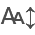

In [1]:
import pandas as pd
import numpy as np
from itables import init_notebook_mode, show, options
init_notebook_mode(all_interactive=True)
import matplotlib.pyplot as plt
import seaborn as sns

Cette analyse exploratoire a pour but de comprendre la structure des données clients, produits et commandes, et d’identifier les premiers patterns comportementaux utiles dans la construction d’un système de recommandation de produits (verres ou montures). Elle vise également à détecter les éventuelles anomalies, biais ou segmentations intéressantes.

# **Chargement datasets**

In [2]:
# Chargement des données
clients = pd.read_csv('../backend/data/clients 2.csv', sep=';')
commandes = pd.read_csv('../backend/data/commandes 2.csv', sep=';')
prescriptions = pd.read_csv('../backend/data/prescriptions 2.csv', sep=';')
montures = pd.read_csv('../backend/data/produits_montures 2.csv', sep=';')
verres = pd.read_csv('../backend/data/produits_verres 2.csv', sep=';')

# **Fusion des tables**

In [3]:
# Fusion commandes + clients
df = commandes.merge(clients, on='Client_ID', how='left')

# Fusion avec montures
df = df.merge(montures, on='Monture_ID', how='left')

# Afficher les premières lignes
df.head()

Commande_ID Client_ID  Verre_ID Monture_ID Date_Commande  Statut  \
0        COM1  CLI85894  VER66477   MON14150    2024-11-21  Livree   
1        COM2  CLI78693  VER33250   MON98676    2024-12-01  Livree   
2        COM3  CLI79578  VER57769   MON20808    2024-10-25  Livree   
3        COM4  CLI16507   VER8856   MON92263    2024-08-23  Livree   
4        COM5  CLI19635  VER79342   MON29264    2024-12-18  Livree   

   Montant_Total (€) Methode_Paiement  \
0             543.97               CB   
1             754.56               CB   
2             215.72               CB   
3             404.84               CB   
4             614.38               CB   

                            Adresse_Livraison    Canal  ...   Marque Modele  \
0   62, rue Isabelle Petitjean,34246 Chretien  Magasin  ...   Oakley  Fd463   
1     89, rue Traore,12843 Saint Alix-sur-Mer  Magasin  ...  Ray-Ban  iL468   
2  82, rue Mathilde Herve,60843 BertrandVille  Magasin  ...   Oakley  CL420   
3     45, rue Tristan Dupre,60751 BaillyBourg  Magasin  ...  Ray-Ban  ZB344   
4         chemin Claudine Leconte,25747 Boyer  Magasin  ...  Ray-Ban  NH836   

           Type     Forme   Materiau      Couleur     Taille Prix (€)  \
0       Cerclee     Ronde  Plastique  Transparent  55-17-134   279.98   
1  Semi-cerclee  Aviateur      Metal  Transparent  58-15-139   428.57   
2       Cerclee     Ronde     Titane      Ecaille  51-15-136    76.73   
3       Cerclee  Aviateur  Plastique         Noir  58-18-141   105.85   
4       Cerclee  Aviateur  Plastique         Noir  59-14-147   369.39   

      Style Stock  
0     Sport    38  
1  Business    50  
2     Sport    12  
3      Luxe    26  
4    Casual    23  

[5 rows x 34 columns]

In [4]:
df.shape

(100000, 34)

# **Nettoyage des données**

In [5]:
df_clean = df.copy()

# --- 1. SUPPRIMER les colonnes inutiles (adresse, email, téléphone, etc.)
colonnes_a_supprimer = [
    'Adresse', 'Email', 'Telephone', 'Adresse_Livraison', 'Nom', 'Prenom', 'Statut', 'Montant_Total (€)', 'Methode_Paiement',
    'Ville', 'Code_Postal', 'Pays', 'Commande_ID', 'Date_Commande', 'Client_ID', 'Verre_ID', 
    'Prix (€)', 'Frequence_Achat', 'Stock', 'Canal' , 'Mode_Paiement_Favori', 'Preferences_Communication',
    'Modele', "Retours"
]
df_clean.drop(columns=[col for col in colonnes_a_supprimer if col in df_clean.columns], inplace=True)
df_clean.set_index('Monture_ID', inplace=True)
df_clean.columns

Index(['Date_Naissance', 'Genre', 'Marque', 'Type', 'Forme', 'Materiau',
       'Couleur', 'Taille', 'Style'],
      dtype='object')

In [6]:
# Convertir la date de naissance en âge
df_clean['Date_Naissance'] = pd.to_datetime(df_clean['Date_Naissance'], errors='coerce')
df_clean['Age'] = pd.Timestamp.now().year - df_clean['Date_Naissance'].dt.year
df_clean.drop(columns=['Date_Naissance'], inplace=True)
df_clean.head()

Genre   Marque          Type     Forme   Materiau  \
Monture_ID                                                            
MON14150          Homme   Oakley       Cerclee     Ronde  Plastique   
MON98676    Non-binaire  Ray-Ban  Semi-cerclee  Aviateur      Metal   
MON20808    Non-binaire   Oakley       Cerclee     Ronde     Titane   
MON92263          Homme  Ray-Ban       Cerclee  Aviateur  Plastique   
MON29264          Femme  Ray-Ban       Cerclee  Aviateur  Plastique   

                Couleur     Taille     Style  Age  
Monture_ID                                         
MON14150    Transparent  55-17-134     Sport   39  
MON98676    Transparent  58-15-139  Business   27  
MON20808        Ecaille  51-15-136     Sport   74  
MON92263           Noir  58-18-141      Luxe   36  
MON29264           Noir  59-14-147    Casual   20

In [7]:
# Verifier les valeurs manquantes
df_clean.isna().sum()

Genre       0
Marque      0
Type        0
Forme       0
Materiau    0
Couleur     0
Taille      0
Style       0
Age         0
dtype: int64

In [8]:
df_clean.duplicated().sum()  # Supprimer les lignes avec des valeurs manquantes

np.int64(346)

In [9]:
df_clean.drop_duplicates(inplace=True)

# **Statistiques descriptives**

In [10]:
# Statistiques descriptives
print("\nStatistiques descriptives :")
display(df_clean.describe())


Statistiques descriptives :


Age
count  99654.000000
mean      50.073274
std       18.205793
min       18.000000
25%       34.000000
50%       50.000000
75%       66.000000
max       81.000000

# **Exploration des données**


Distribution des colonnes numériques :


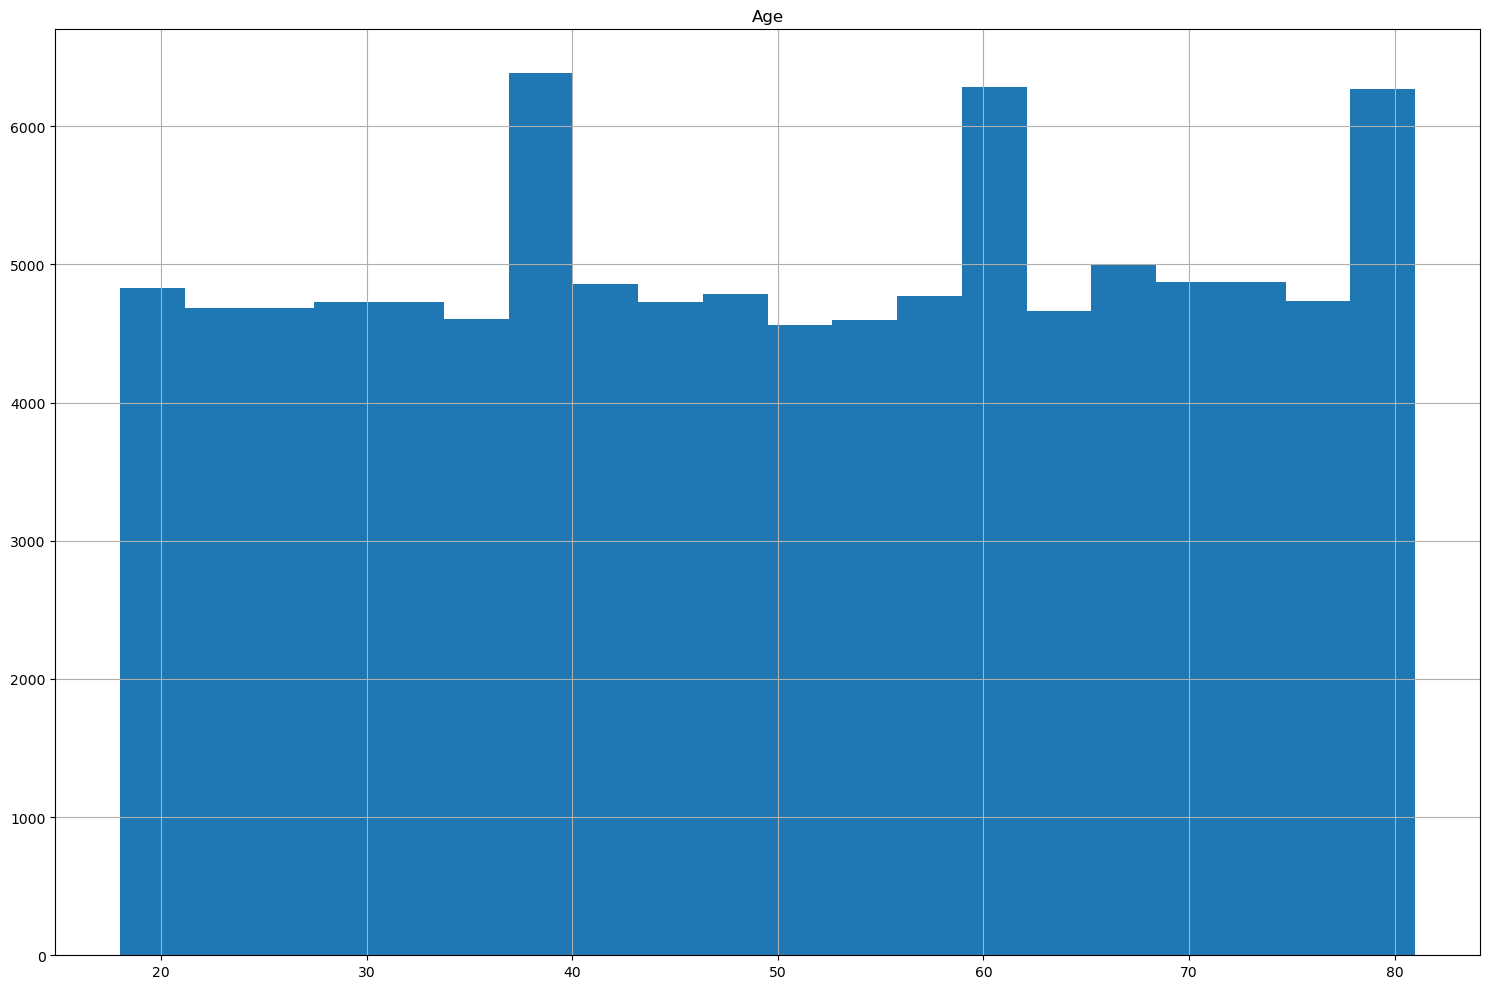

In [11]:
# Distribution des colonnes numériques
print("\nDistribution des colonnes numériques :")
df_clean.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

Les clients ont des âges compris entre environ 18 ans et 80 ans.

Les âges semblent bien répartis, ce qui indique une clientèle variée en termes d'âge.

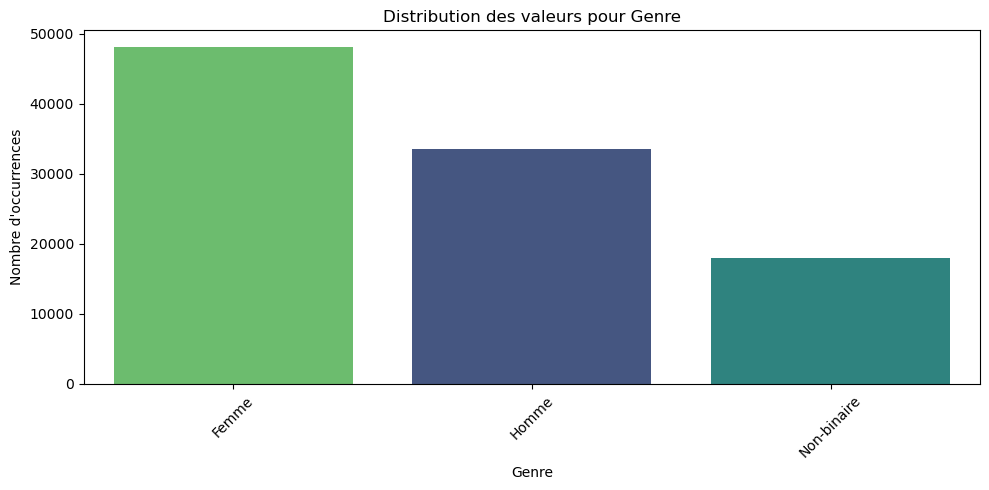

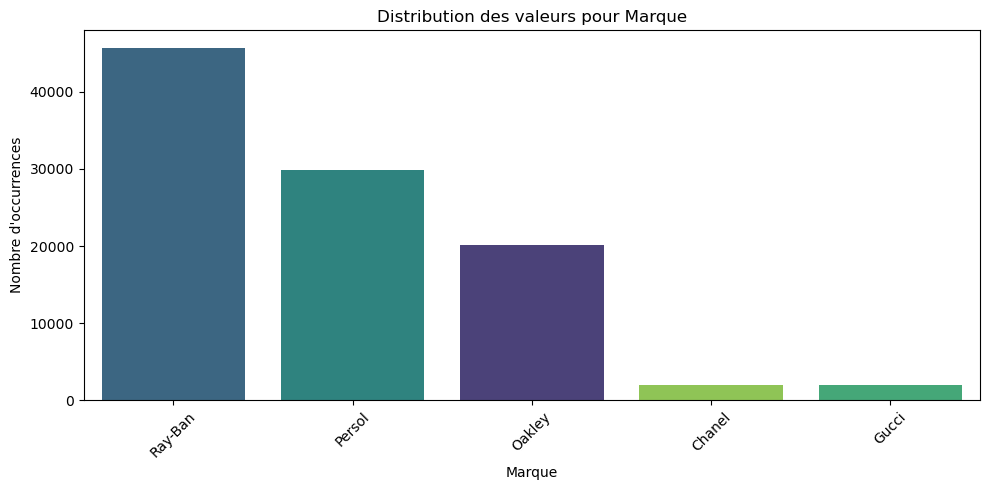

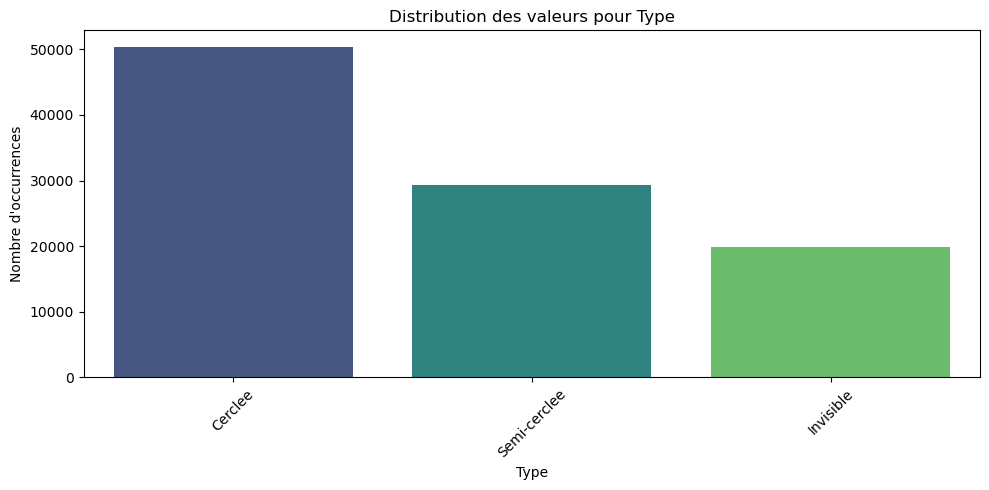

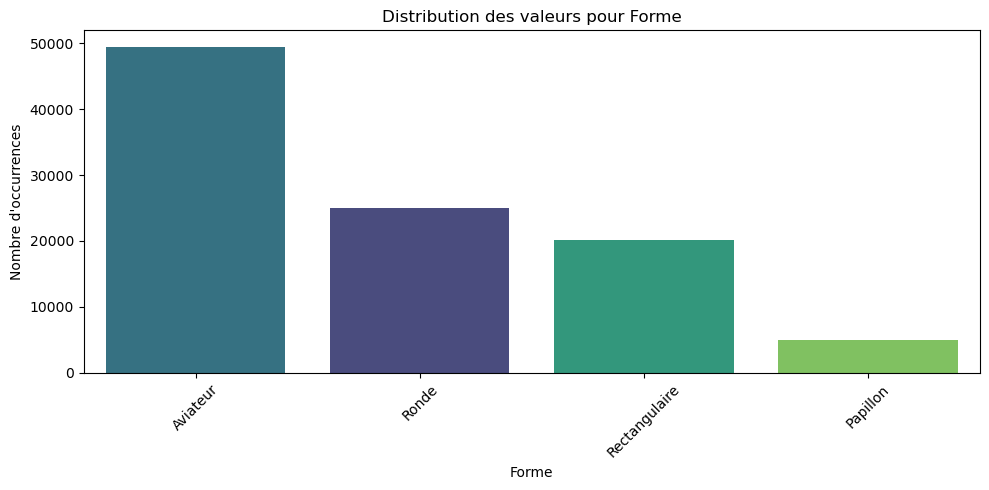

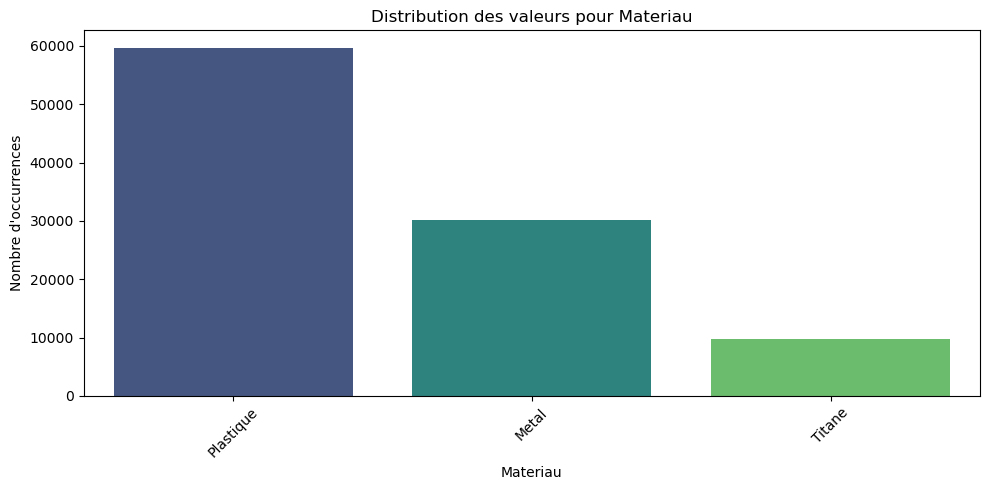

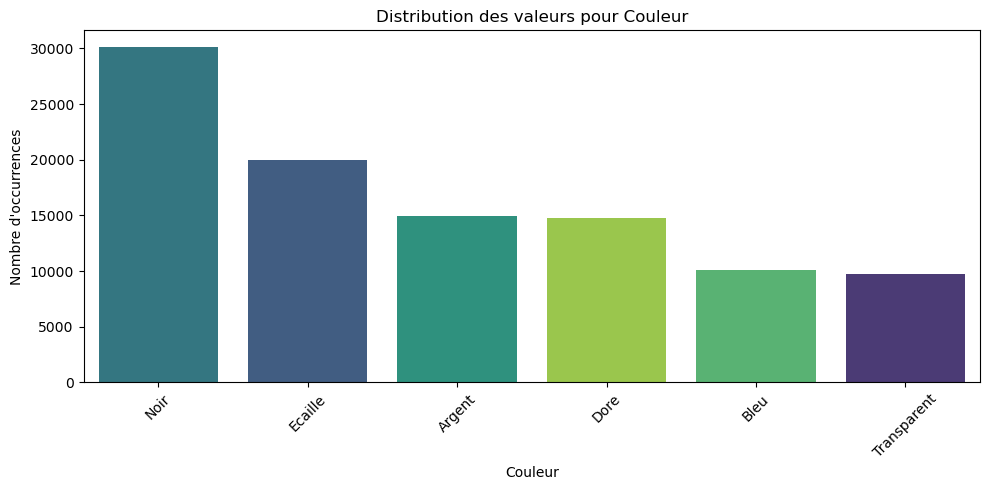

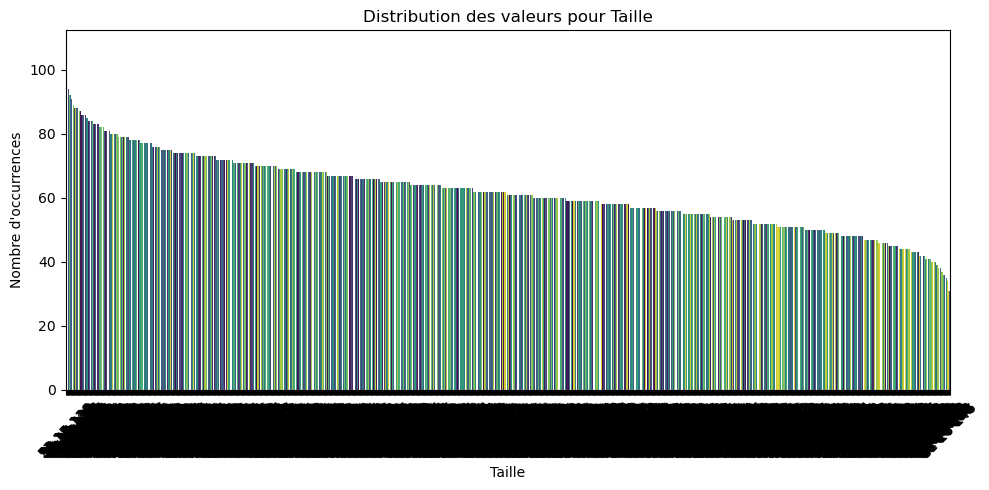

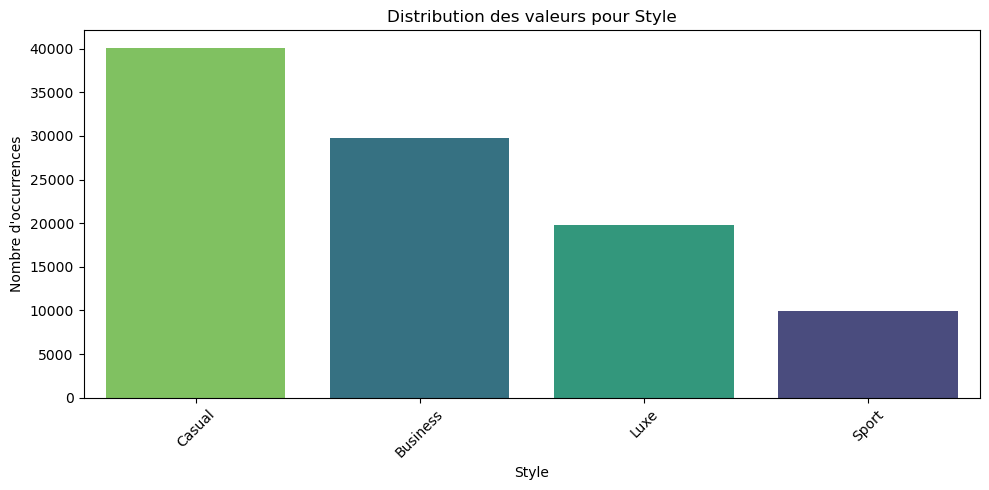

In [12]:
categorical_columns = df_clean.select_dtypes(include=['object']).columns

for col in categorical_columns:    
    # Création d'un diagramme à barres
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_clean, x=col, hue= col, order=df_clean[col].value_counts().index, palette="viridis")
    plt.title(f"Distribution des valeurs pour {col}")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Nombre d'occurrences")
    plt.tight_layout()
    plt.show()

Dans le premier graphique, on observe une domination marquée du genre féminin, avec environ 48 000 clientes recensées. Les hommes suivent avec environ 34 000 individus, tandis que le genre non-binaire représente près de 18 000 clients. Cette répartition montre que les femmes constituent le groupe majoritaire dans ce jeu de données, représentant approximativement la moitié de l’ensemble des clients.

Le deuxième graphique à barres illustre la fréquence des marques de lunettes présentes dans le dataset. Il permet de visualiser quelles marques sont les plus populaires ou les plus représentées dans les données, ce qui est crucial pour un système de recommandation, car cela oriente les produits proposés aux utilisateurs. On constate une forte domination de la marque Ray-Ban, avec environ 45 000 occurrences, suivie de Persol avec environ 30 000, puis Oakley avec un peu plus de 20 000. À l’inverse, Chanel et Gucci sont très peu représentées, avec chacune environ 2 000 occurrences.  
Cette distribution montre une concentration importante autour de quelques marques, ce qui peut refléter :  
- une préférence réelle des clients pour ces marques populaires,  
- une offre plus large ou plus accessible de ces marques dans le catalogue proposé,  
- ou un biais dans la génération ou l’échantillonnage des données.

Le troisième graphique présente la distribution des types de montures dans la base de données de recommandation de lunettes. On y observe une forte prédominance des montures cerclées, qui représentent la majorité des occurrences. Les montures semi-cerclées sont nettement moins présentes, suivies par les montures invisibles, encore plus rares.

Le quatrième graphique montre la répartition des matériaux utilisés dans les montures de lunettes présentes dans la base de données. On constate une nette domination des montures en plastique, suivies par celles en métal, tandis que les montures en titane restent très minoritaires.

Le graphique numéro cinq illustre la répartition des couleurs de montures dans la base de données. On observe que la couleur noire domine très nettement, suivie de la couleur écaille. Les montures argentées et dorées sont relativement équilibrées, tandis que les couleurs bleu et transparent sont plus rares.  
Cette distribution montre une préférence marquée pour des couleurs classiques et discrètes, ce qui pourrait orienter les recommandations vers des styles plus sobres et conventionnels. Cependant, cela peut limiter les options pour les utilisateurs recherchant des montures plus originales ou moins communes.

Le dernier graphique montre la distribution des différents styles de lunettes présents dans le jeu de données. On y observe une répartition clairement déséquilibrée entre les styles :  
- Le style *Casual* est de loin le plus représenté, avec environ 40 000 occurrences, reflétant une forte popularité ou une grande disponibilité sur le marché.  
- Le style *Business* arrive en deuxième position avec près de 30 000 occurrences, ce qui suggère qu’il s’agit également d’un choix courant, probablement lié à un usage quotidien ou professionnel.  
- Le style *Luxe*, bien qu’important, reste en retrait avec environ 20 000 occurrences, ce qui pourrait s’expliquer par un positionnement plus haut de gamme et donc moins répandu.  
- Enfin, le style *Sport* est le moins fréquent, avec près de 10 000 occurrences, ce qui peut refléter une utilisation plus spécifique ou une cible de niche.

In [13]:
df_clean['Marque'].unique()

array(['Oakley', 'Ray-Ban', 'Persol', 'Gucci', 'Chanel'], dtype=object)

In [15]:
# Exporter le DataFrame nettoyé
df_clean.to_csv('../backend/data/df_clean.csv', sep=';')